### Q&A — Feature Description

# Feature Description

---

## Q1. What is an interest point, and what makes a feature “interesting”?

**Answer:**  
An **interest point** is a distinctive location in an image where intensity patterns vary strongly in multiple directions.

**Desirable properties:**
- Repeatable under scale, rotation, illumination.  
- Distinctive and rich local information.  
- Locally computable and efficient.  
- **Edges** are not good (variation only in one direction).  
- **Blobs** are better (variation in multiple directions).  

---

## Q2. How are blobs detected using the Laplacian of Gaussian (LoG)?

**Answer:**  
A **blob** is a region that differs in brightness compared to its surroundings.  

**LoG operator:**
$$
\nabla^2 G(x,y,\sigma) * I(x,y)
$$
where $G(x,y,\sigma)$ is a Gaussian kernel with scale $\sigma$, and $I(x,y)$ is the image.

**Normalized Laplacian:**
$$
\sigma^2 \nabla^2 G(x,y,\sigma)
$$

- Achieves **scale invariance**.  
- **Characteristic scale** = blob size → detected where normalized response is extremal.  

---

## Q3. Why is a scale space required in feature detection?

**Answer:**  
- Features must be detected at **different resolutions**.  
- Objects appear larger/smaller depending on viewpoint.  

**Scale-space construction:**
$$
L(x,y,\sigma) = G(x,y,\sigma) * I(x,y)
$$

- Detect extrema across **space ($x,y$)** and **scale ($\sigma$)**.  

---

## Q4. How does Difference of Gaussians (DoG) approximate LoG?

**Answer:**  
- Computing LoG directly is expensive.  
- DoG = subtraction of Gaussians at two nearby scales:

$$
DoG(x,y,\sigma) = L(x,y,k\sigma) - L(x,y,\sigma)
$$

**Efficient approximation:**
$$
DoG \;\approx\; \sigma^2 \nabla^2 G(x,y,\sigma)
$$

- Used in **SIFT** for scale-space extrema detection.  

---

## Q5. Describe the four main stages of the SIFT algorithm.

**Answer:**
1. **Scale-space extrema detection** → use DoG to find candidate keypoints.  
2. **Keypoint localization** → remove low contrast points & edge responses (using Hessian).  
3. **Orientation assignment** → assign dominant gradient orientation (rotation invariance).  
4. **Descriptor computation** → build histogram of local gradients around keypoint → 128-D vector.  

---

## Q6. Why is orientation assignment important in SIFT?

**Answer:**  
- Ensures descriptors are **rotation invariant**.  

Orientation from gradients:
$$
\theta(x,y) = \tan^{-1}\left(\frac{I_y}{I_x}\right), 
\quad m(x,y) = \sqrt{I_x^2 + I_y^2}
$$

- Descriptor is rotated relative to dominant orientation → robustness.  

---

## Q7. What is a SIFT descriptor and how is it built?

**Answer:**  
- A **128-dimensional vector** describing local gradient patterns.

**Steps:**
- Divide $16\times16$ patch around keypoint into $4\times4$ subregions.  
- Each subregion → 8-bin orientation histogram.  
- Concatenate → 128-D vector.  
- Normalize to unit length for illumination invariance.  

---

## Q8. How are SIFT descriptors compared?

**Answer:**  

- **Euclidean distance (L2 norm):**
$$
d(f_1,f_2) = \sum_i (f_{1i} - f_{2i})^2
$$

- Normalized correlation.  
- Histogram intersection.  
- **Lowe’s ratio test:**  
Accept a match if:
$$
\frac{d_1}{d_2} < 0.75
$$
where $d_1, d_2$ are closest and second-closest matches.  

---

## Q9. Explain the feature matching pipeline.

**Answer:**  
- **Detection** → find keypoints (SIFT/ORB/Harris).  
- **Description** → compute local descriptors.  
- **Matching** → compare descriptors (distance metrics + ratio test).  

---

## Q10. How is homography used in image stitching?

**Answer:**  
- Homography relates two images of a planar surface:

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} \sim
H \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}, \quad
H = \begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33}
\end{bmatrix}
$$

- Requires ≥4 point correspondences.  
- Estimated using **RANSAC** to reject outliers.  

---

## Q11. Why is RANSAC needed in image stitching?

**Answer:**  
- Matches may contain **outliers** (noise, repetitive patterns, occlusions).  

**RANSAC process:**
1. Randomly select 4 points.  
2. Compute homography.  
3. Count inliers.  
4. Repeat → choose best model.  

- Ensures **robustness** to incorrect matches.  

---

## Q12. What is the difference between forward and backward warping?

**Answer:**  
- **Forward warping:** project source → target (may cause holes).  
- **Backward warping:** each target pixel finds corresponding source pixel.  
- Backward is preferred in practice.  

---

## Q13. How is blending used in panorama stitching?

**Answer:**  
- After alignment, seams may appear.  

**Blending techniques:**
- Linear blending (cross-dissolve).  
- Multi-band blending (Laplacian pyramids).  

- Ensures **seamless transition** and reduces ghosting.  

---

# 🎯 Summary of Likely Exam Focus
- **Blob detection:** LoG, DoG  
- **SIFT pipeline:** detection → orientation → descriptor → matching  
- **Ratio test & descriptor comparison**  
- **Homography & RANSAC**  
- **Image stitching pipeline:** warping + blending  



Projective Geometry & Homography
# 📘 Exam Q&A — Homography

---

## Q1. What is Homography and how is it computed?

**Answer:**  
A **homography** is a $3 \times 3$ transformation matrix that maps points between two planes (e.g., two images of the same planar surface).

**Relation:**
$$
\begin{bmatrix}
x' \\ 
y' \\ 
1
\end{bmatrix}
\;\sim\;
H
\begin{bmatrix}
x \\ 
y \\ 
1
\end{bmatrix}
$$

where $H$ is the **homography matrix**.

- Requires at least **4 point correspondences** between the two planes.  
- Can be solved using **Direct Linear Transformation (DLT)**.  
- In practice, **RANSAC** is often used to make the estimation robust to outliers.  



In [7]:
import cv2
import numpy as np

# Example source and destination points
# 👇 Cheat: Replace with your own 4+ matched points
pts_src = np.array([[100,100], [200,100], [200,200], [100,200]])
pts_dst = np.array([[80,120], [220,100], [220,220], [80,240]])

# Compute Homography
# 👇 Cheat: Change cv2.RANSAC to 0 if no outlier rejection is needed
H, mask = cv2.findHomography(pts_src, pts_dst, cv2.RANSAC)

print("Homography Matrix:\n", H)


Homography Matrix:
 [[  1.4   0.  -60. ]
 [ -0.2   1.2  20. ]
 [  0.    0.    1. ]]


Follow-up Q: Why do we need RANSAC when estimating homography?

Answer: To eliminate outliers from false matches and ensure robust estimation

Q2. How do you warp an image using homography?

Answer:

Once homography $H$ is computed, warp the image with cv2.warpPerspective.

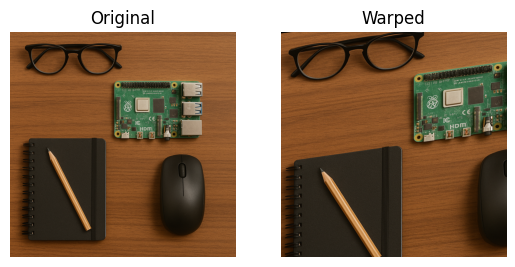

In [9]:
import matplotlib.pyplot as plt

img = cv2.imread("assets/photo.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# Warp image
# 👇 Cheat: Change (w,h) to control canvas size of output
warped = cv2.warpPerspective(img, H, (w, h))

plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Warped"); plt.axis("off")
plt.show()


Follow-up Q: Difference between forward warping and backward warping?

Forward → project source pixels to target (may leave gaps).

Backward → for each target pixel, sample from source (preferred).

Q3. What is the difference between Affine and Projective transformations?

Answer:

Affine: preserves parallelism (6 DOF).

Projective (Homography): allows perspective distortion (8 DOF).

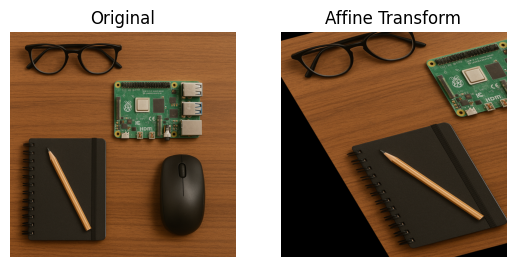

In [10]:
# Affine transform
# 👇 Cheat: pts1 and pts2 must each have 3 points
pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

M = cv2.getAffineTransform(pts1, pts2)
affine = cv2.warpAffine(img, M, (w, h))

plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(affine, cv2.COLOR_BGR2RGB))
plt.title("Affine Transform"); plt.axis("off")
plt.show()


Follow-up Q: Why is projective transform more general?

Answer: Because it models perspective projection (camera geometry), not just scaling/rotation/shearing.

Q4. How does SIFT feature detection and matching help in estimating homography?

Answer:

SIFT detects scale & rotation-invariant features.

Matching descriptors across images → candidate correspondences.

Use cv2.findHomography with RANSAC to estimate $H$.

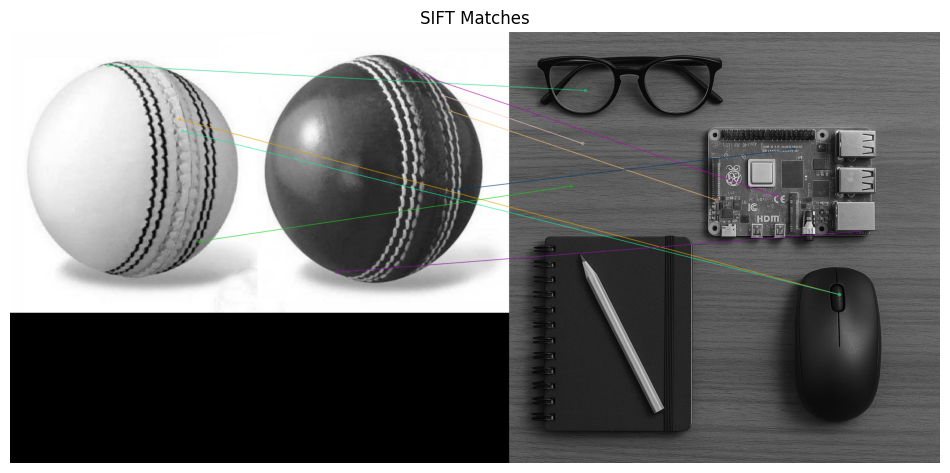

In [16]:
img1 = cv2.imread("assets/redball.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("assets/photo.png", cv2.IMREAD_GRAYSCALE)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Lowe’s ratio test
good = []
for m,n in matches:
    # 👇 Cheat: Change 0.75 → 0.6 (stricter) or 0.85 (looser)
    if m.distance < 0.75 * n.distance:
        good.append(m)

# Draw top 20 matches
match_img = cv2.drawMatches(img1, kp1, img2, kp2, good[:20], None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12,6))
plt.imshow(match_img, cmap="gray")
plt.title("SIFT Matches")
plt.axis("off")
plt.show()


Follow-up Q: Why is Lowe’s ratio test necessary?

Answer: It filters out ambiguous matches by ensuring the best match is significantly better than the second-best.

Q5. How can you perform image stitching using homography?

Answer:

Steps: detect features → match → compute homography → warp → blend.

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images (grayscale for matching, RGB for display)
img1 = cv2.imread("assets/photo.png")
img2 = cv2.imread("assets/redball.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# SIFT keypoints and descriptors
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Brute Force Matcher
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Lowe’s ratio test
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:  # 👈 Cheat: adjust 0.75
        good.append(m)

print("Number of good matches:", len(good))

# Ensure enough matches
if len(good) > 4:
    # Extract matched points
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # Compute homography
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # Warp first image into panorama space
    height, width, channels = img2.shape
    result = cv2.warpPerspective(img1, H, (width + img1.shape[1], height))
    result[0:height, 0:width] = img2

    # Show result
    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Stitched Panorama")
    plt.axis("off")
    plt.show()
else:
    print("Not enough matches to compute homography!")


Number of good matches: 4
Not enough matches to compute homography!


Cheat Notes

0.75 in ratio test → lower (0.6) = stricter matches, higher (0.85) = more matches but noisier.

Canvas size (width + img1.shape[1], height) → increase the first dimension if panorama is cut off.

if len(good) > 4: ensures no crash when matches are insufficient.

Follow-up Q: Why do we need blending in stitching?\

Answer: To remove seams/ghosting caused by illumination changes or imperfect alignment.

Q6. Application of Homography in Augmented Reality Augmented Reality (Overlay Logo with Homography)

Q: How can homography be used to overlay an object (e.g., logo) onto a detected surface?

Answer:

Map 4 corners of virtual object → 4 corners of detected surface using $H$.

Warp object image and overlay.

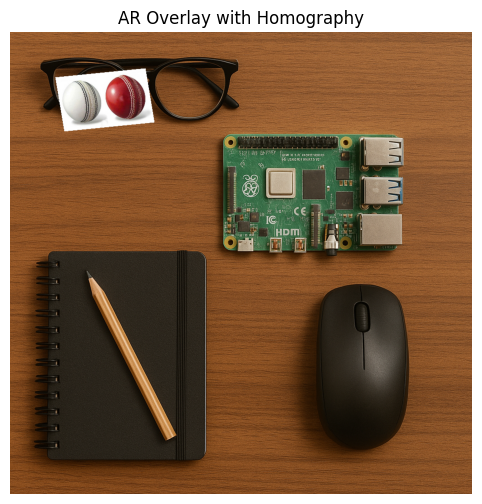

In [15]:
scene = cv2.imread("assets/photo.png")
logo = cv2.imread("assets/redball.jpg")

h, w = logo.shape[:2]

# 👇 Cheat: Change these points to the 4 corners in the scene where you want to place the logo
pts_logo = np.array([[0,0],[w,0],[w,h],[0,h]])
pts_scene = np.array([[100,100],[300,80],[320,200],[120,220]])

# Homography
H, _ = cv2.findHomography(pts_logo, pts_scene)

# Warp logo
overlay = cv2.warpPerspective(logo, H, (scene.shape[1], scene.shape[0]))

# Combine overlay with scene
mask = (overlay > 0)
scene[mask] = overlay[mask]

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.title("AR Overlay with Homography")
plt.axis("off")
plt.show()


# 📘 Exam Q&A — Homography with DLT

---

## Q7. How to compute Homography using DLT (theory-based + example)

**Answer (theory):**  
Given correspondences $(x,y) \leftrightarrow (x',y')$, each pair gives two equations:

\[
x' = \frac{h_{11}x + h_{12}y + h_{13}}{h_{31}x + h_{32}y + h_{33}}, 
\quad
y' = \frac{h_{21}x + h_{22}y + h_{23}}{h_{31}x + h_{32}y + h_{33}}
\]

This can be rearranged into **linear equations** in terms of the homography vector  
$\mathbf{h} = [h_{11}, h_{12}, h_{13}, h_{21}, h_{22}, h_{23}, h_{31}, h_{32}, h_{33}]^T$:

\[
\begin{bmatrix}
x & y & 1 & 0 & 0 & 0 & -x x' & -y x' & -x' \\
0 & 0 & 0 & x & y & 1 & -x y' & -y y' & -y'
\end{bmatrix}
\mathbf{h} = 0
\]

Stacking equations from **at least 4 correspondences** gives a system:

\[
A \mathbf{h} = 0
\]

The solution $\mathbf{h}$ is the **eigenvector** of $A^T A$ corresponding to the smallest eigenvalue, usually found with **SVD**.

---

## ✅ Example: Computing $H$ from 4 correspondences

Suppose we have 4 point correspondences:

- $(0,0) \leftrightarrow (0,0)$  
- $(1,0) \leftrightarrow (2,0)$  
- $(1,1) \leftrightarrow (2,2)$  
- $(0,1) \leftrightarrow (0,2)$  

### Step 1: Build equations for each pair

For $(x,y) = (1,0) \to (x',y') = (2,0)$:

\[
\begin{bmatrix}
1 & 0 & 1 & 0 & 0 & 0 & -2 & 0 & -2 \\
0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0
\end{bmatrix}
\]

For $(x,y) = (1,1) \to (2,2)$:

\[
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 & 0 & -2 & -2 & -2 \\
0 & 0 & 0 & 1 & 1 & 1 & -2 & -2 & -2
\end{bmatrix}
\]

For $(x,y) = (0,1) \to (0,2)$:

\[
\begin{bmatrix}
0 & 1 & 1 & 0 & 0 & 0 & 0 & -2 & -2 \\
0 & 0 & 0 & 0 & 1 & 1 & 0 & -2 & -2
\end{bmatrix}
\]

(And similarly for $(0,0) \to (0,0)$ which contributes trivial equations).

---

### Step 2: Stack into matrix $A$

\[
A =
\begin{bmatrix}
1 & 0 & 1 & 0 & 0 & 0 & -2 & 0 & -2 \\
0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 \\
1 & 1 & 1 & 0 & 0 & 0 & -2 & -2 & -2 \\
0 & 0 & 0 & 1 & 1 & 1 & -2 & -2 & -2 \\
0 & 1 & 1 & 0 & 0 & 0 & 0 & -2 & -2 \\
0 & 0 & 0 & 0 & 1 & 1 & 0 & -2 & -2
\end{bmatrix}
\]

---

### Step 3: Solve $A \mathbf{h} = 0$ using SVD

- Compute $A^T A$ and find eigenvector with smallest eigenvalue.  
- Reshape $\mathbf{h}$ into $3 \times 3$ matrix $H$.  

Resulting homography (ideal case):

\[
H =
\begin{bmatrix}
2 & 0 & 0 \\
0 & 2 & 0 \\
0 & 0 & 1
\end{bmatrix}
\]

---

### Interpretation
This $H$ corresponds to a **scaling transform** by factor of 2 in both $x$ and $y$, which matches the given correspondences.

---
